<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 7, Chronos-2 para Pasajeros de Aerolinea**

---

In [ ]:
!pip install -q "chronos-forecasting>=2.0"

In [ ]:

import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Descargamos el dataset

In [ ]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
raw = pd.read_csv(URL, parse_dates=["Month"])

df = (raw.rename(columns={"Month": "timestamp", "Passengers": "target"})
         .assign(item_id="pasajeros")[["item_id", "timestamp", "target"]])

df.tail(3)

,item_id,timestamp,target
141,pasajeros,1960-10-01,461
142,pasajeros,1960-11-01,390
143,pasajeros,1960-12-01,432


Como esta serie es **mensual** (no diaria, como las de las clases
anteriores), tiene más sentido pedir un horizonte en meses. Pedimos 12 pasos,
es decir, un año hacia adelante.

In [ ]:
H = 12
pred = pipe.predict_df(df, prediction_length=H)
pred

,item_id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,pasajeros,1961-01-01,target,446.628845,428.646423,436.071838,440.625305,442.935699,446.628845,449.498474,453.506592,458.083374,465.863831
1,pasajeros,1961-02-01,target,426.865509,406.524292,413.794952,418.977173,422.708862,426.865509,429.873718,433.653320,439.520996,448.226318
2,pasajeros,1961-03-01,target,495.672729,469.793640,479.612122,485.518951,490.365936,495.672729,499.510071,503.735840,510.077545,515.700562
3,pasajeros,1961-04-01,target,491.289307,468.102081,477.069000,482.249023,487.306183,491.289307,496.909363,500.579285,506.346558,513.527039
4,pasajeros,1961-05-01,target,501.775635,475.013397,485.214508,492.703644,497.830444,501.775635,506.708313,512.235596,520.261475,528.136658
5,pasajeros,1961-06-01,target,572.614319,542.536133,555.022339,562.843506,568.592529,572.614319,580.103271,584.505005,592.769958,604.917419
6,pasajeros,1961-07-01,target,642.116943,606.537415,619.192566,630.517517,638.164490,642.116943,650.357666,655.790161,666.168091,680.088867
7,pasajeros,1961-08-01,target,644.543579,605.710693,619.969421,631.318970,636.546997,644.543579,652.221436,660.829224,670.458618,684.778259
8,pasajeros,1961-09-01,target,553.622192,513.467957,528.787598,537.375488,545.480591,553.622192,558.798523,565.103394,573.419189,586.735962
9,pasajeros,1961-10-01,target,482.127686,448.387634,460.574341,468.821655,475.531372,482.127686,487.579529,494.690125,502.657745,514.832581


In [ ]:
print(list(pred.columns))

['item_id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']


Elegimos los niveles `quantile_levels` acepta la lista que quieras. Podemos pedir solo los que
vamos a usar.

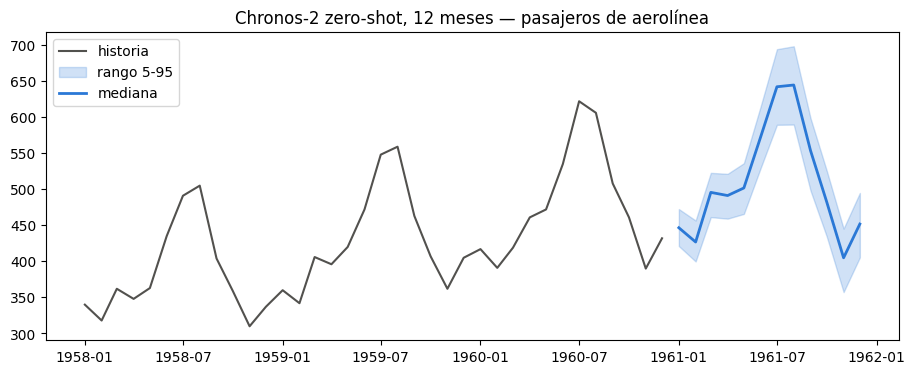

In [ ]:
pred = pipe.predict_df(
    df,
    prediction_length=H,
    quantile_levels=[0.05, 0.5, 0.95],    # nivel 5, mediana, nivel 95
)
pred[["timestamp", "0.05", "0.5", "0.95"]].round(0).head()

pred["timestamp"] = pd.to_datetime(pred["timestamp"])
x = pred.timestamp.values
ultimos = df.tail(36)   # últimos 3 años

plt.figure(figsize=(11, 4))
plt.plot(ultimos.timestamp.values, ultimos.target.values, color="#52514e", label="historia")
plt.fill_between(x, pred["0.05"], pred["0.95"], color="#2a78d6", alpha=.22, label="rango 5-95")
plt.plot(x, pred["0.5"], color="#2a78d6", lw=2, label="mediana")
plt.legend(); plt.title("Chronos-2 zero-shot, 12 meses — pasajeros de aerolínea");


Varias series de una vez.

Si la tabla tiene más de un `item_id`, las pronostica todas en una llamada.
No hace falta un loop.

AirPassengers trae una sola serie, así que armamos una segunda a partir de la
misma columna `Passengers`, aplicando la transformación clásica para este
dataset:

* `pasajeros`: la serie original, en su escala natural (miles de pasajeros).
* `log_pasajeros`: la misma serie en escala logarítmica. Como la
  estacionalidad de esta serie es multiplicativa (los picos de diciembre son
  cada vez más grandes en términos absolutos, pero proporcionalmente
  parecidos), el logaritmo la vuelve aproximadamente aditiva.

Son la misma información en dos escalas distintas, así que es un buen caso
para comparar el pronóstico en paralelo

In [ ]:
panel = pd.concat([
    raw.rename(columns={"Month": "timestamp", "Passengers": "target"}).assign(item_id="pasajeros"),
    raw.assign(target=np.log(raw["Passengers"])).rename(columns={"Month": "timestamp"}).assign(item_id="log_pasajeros"),
])[["item_id", "timestamp", "target"]]

pred_panel = pipe.predict_df(panel, prediction_length=H)
pred_panel.groupby("item_id").head(2)[["item_id", "timestamp", "0.5"]].round(2)


,item_id,timestamp,0.5
0,pasajeros,1961-01-01,446.630005
1,pasajeros,1961-02-01,426.869995
12,log_pasajeros,1961-01-01,6.110000
13,log_pasajeros,1961-02-01,6.070000


Cross_learning


Que las series se miren entre sí

Por defecto cada serie se pronostica por separado. Con `cross_learning=True`,
el modelo mira todas las series del lote a la vez y comparte información
entre ellas.

Sirve cuando las series están relacionadas y cada una tiene poca historia, acá `log_pasajeros` es literalmente una transformación de `pasajeros`, así
que es un caso bastante extremo de series relacionadas, pero **no siempre
mejora**

In [ ]:
pred_cl = pipe.predict_df(panel, prediction_length=H, cross_learning=True)
pred_cl.groupby("item_id").head(2)[["item_id", "timestamp", "0.5"]].round(2)

,item_id,timestamp,0.5
0,pasajeros,1961-01-01,444.690002
1,pasajeros,1961-02-01,423.559998
12,log_pasajeros,1961-01-01,6.110000
13,log_pasajeros,1961-02-01,6.060000


Covariables futuras conocidas

Acá la covariable más natural es `temporada_alta`: un indicador de si el mes
es de vacaciones (junio, julio, agosto y diciembre, que son justamente los
meses donde se ven los picos en el gráfico).

In [ ]:
hist = df.assign(
    temporada_alta=df["timestamp"].dt.month.isin([6, 7, 8, 12]).astype(int)
)

pasado = hist.iloc[:-H]    # historia + covariable
futuro = hist.iloc[-H:][["item_id", "timestamp", "temporada_alta"]]  # solo covariable

pred_cov = pipe.predict_df(pasado, future_df=futuro, prediction_length=H)
pred_cov[["timestamp", "0.1", "0.5", "0.9"]].round(0).head()

,timestamp,0.1,0.5,0.9
0,1960-01-01,395.0,411.0,428.0
1,1960-02-01,379.0,396.0,413.0
2,1960-03-01,442.0,464.0,482.0
3,1960-04-01,431.0,447.0,466.0
4,1960-05-01,441.0,461.0,482.0


Multivariado: varios targets a la vez

Si le pasamos una lista en `target`, modela las series juntas, no por
separado. Sirve cuando se mueven de forma relacionada.

Volvemos a usar el par `pasajeros` / `log_pasajeros`, pero ahora en vez de
tratarlas como dos `item_id` distintos, las ponemos
como dos columnas de un mismo `item_id`. La diferencia con `cross_learning`
es conceptual: acá no son "dos series parecidas", son "dos variables de la
misma serie", como abrir/cierre de una acción.

In [ ]:
multi = (raw.rename(columns={"Month": "timestamp", "Passengers": "pasajeros"})
             .assign(log_pasajeros=lambda t: np.log(t["pasajeros"]),
                      item_id="pasajeros_ml")
             [["item_id", "timestamp", "pasajeros", "log_pasajeros"]])

pred_multi = pipe.predict_df(multi, prediction_length=H, target=["pasajeros", "log_pasajeros"])
pred_multi.groupby("target_name").head(2)[["target_name", "timestamp", "0.5"]].round(2)

,target_name,timestamp,0.5
0,pasajeros,1961-01-01,444.690002
1,pasajeros,1961-02-01,423.559998
12,log_pasajeros,1961-01-01,6.110000
13,log_pasajeros,1961-02-01,6.060000
